In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# --------------------- Import VQNiche ---------------------
from vqniche.utils.parse_test_configs import *
from vqniche.initializers.initialize import *
from vqniche.utils.type_conversions import *
from vqniche.plotting import *

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain

In [3]:
# --------------------- Import Libraries ---------------------
import os
import copy
import sys
import yaml
import pickle
from pathlib import Path
from dataclasses import dataclass

import scanpy as sc
import anndata as ad
import squidpy as sq

import numpy as np
import networkx as nx
import scipy.sparse as sp
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import pytorch_lightning as pl
import torch_geometric.transforms as T
from torch_geometric.data import Batch
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj
from torch_geometric.loader import DataLoader as BatchBuilder

# --------------------- Display Settings ---------------------
# display setting all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [4]:
save_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/tables")
save_dir.mkdir(parents=True, exist_ok=True)

In [5]:
def collect_wandb_run_dirs(
        sweep_dir,
        type_of_run: Literal['run', 'offline-run']='run'
    ):
    wandb_run_dirs = []
    for d in os.listdir(sweep_dir / "wandb"):
        if type_of_run in d:
            # print(d)
            wandb_run_dirs.append(sweep_dir / "wandb" / d)
    return wandb_run_dirs

In [6]:
def build_sweep_test_results_df(
        wandb_run_dirs,
        split: Literal['1-test-patch', '3-test-patch']='1-test-patch',
        conditioning=True
    ):
    wandb_run_dir_dfs = []
    for wandb_run_dir in wandb_run_dirs:
        if isinstance(wandb_run_dir, str):
            cfg = f"{wandb_run_dir}/files/user_specified_config.yaml"
            test_res_file = f"{wandb_run_dir}/files/results/test_metrics.csv"
        else:
            cfg = wandb_run_dir/"files"/"user_specified_config.yaml"
            test_res_file = wandb_run_dir/"files"/"results"/"test_metrics.csv"
        with open(cfg, 'r') as f:
            cfg = yaml.safe_load(f)
        test_results_df = pd.read_csv(test_res_file)
        
        test_results_df['dataset'] = cfg['dataset']['dataset_name']
        test_results_df['seed'] = cfg['experiment']['seed']
        if conditioning:
            test_results_df['model'] = cfg['model']['model_name']
        else:
            test_results_df['model'] = f"{cfg['model']['model_name']} w/o C"
        test_results_df['split'] = split

        wandb_run_dir_dfs.append(test_results_df)
        
    sweep_results = pd.concat(
        objs=wandb_run_dir_dfs,
        ignore_index=True
    )

    return sweep_results

In [7]:
def build_clean_sweep_results_df(
        df: pd.DataFrame,
        metrics: List[str] = [
            "pearson_1hop_nbr",
            "pearson_gene_wise_1hop_nbr",
            "mmd_1hop_nbr",
            "mmd_pca_1hop_nbr",
        ]
    ):
    # --- Step 1: groupby and transpose ---
    df_long = df.melt(
        id_vars=["dataset", "seed", "model", "split"], 
        var_name="metric", 
        value_name="value"
    )
    
    # --- Step 2: strip mode from metric name ---
    df_long["mode"] = df_long["metric"].str.extract(r"^(train|val|test)")
    df_long["metric"] = df_long["metric"].str.replace(r"^(train|val|test)_", "", regex=True)
    df_long = df_long[df_long['metric'].isin(metrics)]

    # --- Step 3: pretty names for metric ---
    metric_rename = {
        "pearson_1hop_nbr": "PC",
        "mmd_1hop_nbr": "MMD",
        "energy_pca_1hop_nbr": "E",
        "energy_1hop_nbr": "E1",
    }
    df_long["metric"] = df_long["metric"].map(metric_rename)

    # --- Step 4: pretty names for model ---
    model_rename = {
        "VQNiche": "SQUINT",
        "VQNiche w/o C": "SQUINT w/o C",
        "WFM": "WFM",
    }
    df_long["model"] = df_long["model"].map(model_rename)
    
    # --- Step 5: pretty names for dataset ---
    dataset_rename = {
        "xhs1000-39b_1p": "Skin (Human)",
        "mmb0-4b_1p": "Brain (Mouse)",
        "xhk1020-CV1-CV2-5b_1p": "Kidney (Human)",
    }
    df_long["dataset"] = df_long["dataset"].map(dataset_rename)
    
    # --- Step 6: pretty names for split ---
    split_rename = {
        "1-test-patch": "1 Patch",
        "3-test-patch": "3 Patches",
    }
    df_long["split"] = df_long["split"].map(split_rename)
    
    # --- Step 7: round to 4 decimals ---
    df_long['value'] = df_long['value'].round(4)
    
    df_long = df_long.drop_duplicates()
    
    return df_long

In [8]:
df_datasets = []
metrics = [
    "pearson_1hop_nbr",
    # "pearson_cell_wise",
    # "pearson_gene_wise_1hop_nbr",
    "mmd_1hop_nbr",
    # "mmd_pca_1hop_nbr",
    # "energy_pca_1hop_nbr",
    "energy_1hop_nbr",
]

## 3 Test Regions

### No Conditioning

In [16]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 32, 12]/spatial_n_neighs_8/seed/20250923-222431")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=False,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.0892,0.393232,0.749560,0.115936,0.283750,0.091297,0.003602,0.012546,6.546565,4,xhs1000-39b_1p,0,VQNiche w/o C,3-test-patch
1,0.0848,0.381634,0.731235,0.108702,0.267174,0.086761,0.003600,0.012633,6.758675,4,xhs1000-39b_1p,2,VQNiche w/o C,3-test-patch
2,0.1022,0.405405,0.760444,0.116421,0.281154,0.081054,0.003590,0.010885,7.151421,4,xhs1000-39b_1p,1,VQNiche w/o C,3-test-patch


,dataset,seed,model,split,metric,value,mode
8,Skin (Human),0,SQUINT w/o C,3 Patches,PC,0.7496,test
9,Skin (Human),2,SQUINT w/o C,3 Patches,PC,0.7312,test
10,Skin (Human),1,SQUINT w/o C,3 Patches,PC,0.7604,test


### Conditioning on RBF Distances + Batch-ID

In [17]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 9, 28, 29, 32, 12]/spatial_n_neighs_8/seed/20250923-220522")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.1610,0.442929,0.784678,0.130476,0.307240,0.098673,0.003606,0.014509,5.483313,4,xhs1000-39b_1p,2,VQNiche,3-test-patch
1,0.1610,0.442929,0.784678,0.130476,0.307240,0.098673,0.003606,0.014509,5.483313,4,xhs1000-39b_1p,2,VQNiche,3-test-patch
2,0.1198,0.437777,0.780558,0.130274,0.309842,0.091400,0.003610,0.012535,6.505773,4,xhs1000-39b_1p,0,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode
8,Skin (Human),2,SQUINT,3 Patches,PC,0.7847,test
10,Skin (Human),0,SQUINT,3 Patches,PC,0.7806,test
11,Skin (Human),1,SQUINT,3 Patches,PC,0.7994,test


### No Conditioning

In [11]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 12]/spatial_n_neighs_8/seed/20250918-122511")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=False,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.151,0.393367,0.727116,0.118851,0.282960,0.091764,0.003596,4,xhs1000-39b_1p,1,VQNiche w/o C,3-test-patch
1,0.105,0.400144,0.725740,0.112954,0.269126,0.096759,0.003591,4,xhs1000-39b_1p,0,VQNiche w/o C,3-test-patch
2,0.128,0.395007,0.727992,0.124209,0.299491,0.095290,0.003609,4,xhs1000-39b_1p,2,VQNiche w/o C,3-test-patch


,dataset,seed,model,split,metric,value,mode
8,Skin (Human),1,SQUINT w/o C,3 Patches,PC,0.7271,test
9,Skin (Human),0,SQUINT w/o C,3 Patches,PC,0.7257,test
10,Skin (Human),2,SQUINT w/o C,3 Patches,PC,0.7280,test


### Conditioning on RBF Distances + Batch-ID

In [12]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhs1000-39b_1p/sweep/VQNiche/batch=[2, 11, 12]/spatial_n_neighs_8/seed/20250918-121510")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long.head(3))

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.1494,0.438878,0.767513,0.127245,0.301352,0.078045,0.003585,4,xhs1000-39b_1p,0,VQNiche,3-test-patch
1,0.1794,0.441650,0.774775,0.127762,0.292029,0.079204,0.003595,4,xhs1000-39b_1p,1,VQNiche,3-test-patch
2,0.1332,0.442483,0.778006,0.130563,0.295166,0.097059,0.003611,4,xhs1000-39b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode
8,Skin (Human),0,SQUINT,3 Patches,PC,0.7675,test
9,Skin (Human),1,SQUINT,3 Patches,PC,0.7748,test
10,Skin (Human),2,SQUINT,3 Patches,PC,0.7780,test


# Dataset: mmb04-4b_1p

## 3 Test Regions

### Conditioning with RBF Distances + Batch-ID: Zero Masking

In [9]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/mmb0-4b_1p/sweep/VQNiche/batch=[0, 1, 2, 3]/spatial_n_neighs_8/seed/20251125-132951")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['Mask'] = 'Zeros'
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,epoch,dataset,seed,model,split
0,0.0310,NaN,0.895817,NaN,0.327599,NaN,0.007678,4,mmb0-4b_1p,1,VQNiche,3-test-patch
1,0.0486,NaN,0.901328,NaN,0.327658,NaN,0.007779,4,mmb0-4b_1p,0,VQNiche,3-test-patch
2,0.0362,NaN,0.898463,NaN,0.327624,NaN,0.007730,4,mmb0-4b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,Mask
8,Brain (Mouse),1,SQUINT,3 Patches,PC,0.8958,test,Zeros
9,Brain (Mouse),0,SQUINT,3 Patches,PC,0.9013,test,Zeros
10,Brain (Mouse),2,SQUINT,3 Patches,PC,0.8985,test,Zeros
20,Brain (Mouse),1,SQUINT,3 Patches,MMD,NaN,test,Zeros
21,Brain (Mouse),0,SQUINT,3 Patches,MMD,NaN,test,Zeros
22,Brain (Mouse),2,SQUINT,3 Patches,MMD,NaN,test,Zeros


### Conditioning with RBF Distances + Batch-ID: Learnable Masking

In [10]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/mmb0-4b_1p/sweep/VQNiche/batch=[0, 1, 2, 3]/spatial_n_neighs_8/seed/20250918-120525")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
df_long['Mask'] = 'Learnable'
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.0976,0.665215,0.906643,0.127004,0.309582,0.037895,0.00246,0.006198,19.380365,mmb0-4b_1p,0,VQNiche,3-test-patch
1,0.1256,0.664743,0.920757,0.126219,0.293255,0.039721,0.00246,0.004190,17.040207,mmb0-4b_1p,1,VQNiche,3-test-patch
2,0.1098,0.665079,0.920793,0.126838,0.298615,0.040766,0.00246,0.004737,18.873299,mmb0-4b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode,Mask
8,Brain (Mouse),0,SQUINT,3 Patches,PC,0.9066,test,Learnable
9,Brain (Mouse),1,SQUINT,3 Patches,PC,0.9208,test,Learnable
10,Brain (Mouse),2,SQUINT,3 Patches,PC,0.9208,test,Learnable
20,Brain (Mouse),0,SQUINT,3 Patches,MMD,0.0379,test,Learnable
21,Brain (Mouse),1,SQUINT,3 Patches,MMD,0.0397,test,Learnable
22,Brain (Mouse),2,SQUINT,3 Patches,MMD,0.0408,test,Learnable
28,Brain (Mouse),0,SQUINT,3 Patches,E1,0.0062,test,Learnable
29,Brain (Mouse),1,SQUINT,3 Patches,E1,0.0042,test,Learnable
30,Brain (Mouse),2,SQUINT,3 Patches,E1,0.0047,test,Learnable


# Dataset: xhk1020-CV1-CV2-5b_1p

## 3 Test Regions

In [20]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/sweep/VQNiche/batch=[0, 1, 2, 3, 4]/spatial_n_neighs_8/seed/20250918-142428")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=False,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.0154,0.413844,0.809109,0.040570,0.296446,0.026088,0.000850,0.004091,0.640712,xhk1020-CV1-CV2-5b_1p,2,VQNiche w/o C,3-test-patch
1,0.0194,0.433439,0.834501,0.044074,0.314543,0.025507,0.000849,0.003954,0.830107,xhk1020-CV1-CV2-5b_1p,0,VQNiche w/o C,3-test-patch
2,0.0154,0.413844,0.809109,0.040570,0.296446,0.026088,0.000850,0.004091,0.640712,xhk1020-CV1-CV2-5b_1p,2,VQNiche w/o C,3-test-patch


,dataset,seed,model,split,metric,value,mode
8,Kidney (Human),2,SQUINT w/o C,3 Patches,PC,0.8091,test
9,Kidney (Human),0,SQUINT w/o C,3 Patches,PC,0.8345,test
11,Kidney (Human),1,SQUINT w/o C,3 Patches,PC,0.8374,test
20,Kidney (Human),2,SQUINT w/o C,3 Patches,MMD,0.0261,test
21,Kidney (Human),0,SQUINT w/o C,3 Patches,MMD,0.0255,test
23,Kidney (Human),1,SQUINT w/o C,3 Patches,MMD,0.0247,test
28,Kidney (Human),2,SQUINT w/o C,3 Patches,E1,0.0041,test
29,Kidney (Human),0,SQUINT w/o C,3 Patches,E1,0.0040,test
31,Kidney (Human),1,SQUINT w/o C,3 Patches,E1,0.0037,test


### Conditioning with RBF Distances + Batch-ID

In [21]:
sweep_dir = Path("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/sweep/VQNiche/batch=[0, 1, 2, 3, 4]/spatial_n_neighs_8/seed/20250918-133207")
wandb_run_dirs = collect_wandb_run_dirs(sweep_dir)
sweep_results = build_sweep_test_results_df(
    wandb_run_dirs,
    split='3-test-patch',
    conditioning=True,
)
display(sweep_results.head(3))

df_long = build_clean_sweep_results_df(
                sweep_results,
                metrics,
            )
display(df_long)

df_datasets.append(df_long)

,test_codebook_utilization,test_pearson_cell_wise,test_pearson_1hop_nbr,test_pearson_gene_wise,test_pearson_gene_wise_1hop_nbr,test_mmd_1hop_nbr,test_mmd_pca_1hop_nbr,test_energy_1hop_nbr,test_energy_pca_1hop_nbr,dataset,seed,model,split
0,0.024,0.508650,0.870048,0.058456,0.365251,0.018435,0.000848,0.002834,1.147923,xhk1020-CV1-CV2-5b_1p,0,VQNiche,3-test-patch
1,0.024,0.501943,0.867359,0.050387,0.366539,0.021097,0.000855,0.003627,1.193336,xhk1020-CV1-CV2-5b_1p,1,VQNiche,3-test-patch
2,0.025,0.497489,0.868739,0.054344,0.371600,0.018810,0.000851,0.002724,1.058001,xhk1020-CV1-CV2-5b_1p,2,VQNiche,3-test-patch


,dataset,seed,model,split,metric,value,mode
8,Kidney (Human),0,SQUINT,3 Patches,PC,0.8700,test
9,Kidney (Human),1,SQUINT,3 Patches,PC,0.8674,test
10,Kidney (Human),2,SQUINT,3 Patches,PC,0.8687,test
20,Kidney (Human),0,SQUINT,3 Patches,MMD,0.0184,test
21,Kidney (Human),1,SQUINT,3 Patches,MMD,0.0211,test
22,Kidney (Human),2,SQUINT,3 Patches,MMD,0.0188,test
28,Kidney (Human),0,SQUINT,3 Patches,E1,0.0028,test
29,Kidney (Human),1,SQUINT,3 Patches,E1,0.0036,test
30,Kidney (Human),2,SQUINT,3 Patches,E1,0.0027,test


# Final Table

In [17]:
df_avg = pd.concat(
            objs=df_datasets,
            ignore_index=True
        )
df_avg = df_avg.groupby(
        ['dataset', 'split', 'model', 'metric', 'Mask']
        )['value'].mean().reset_index()
df_avg = df_avg.round(4)
display(df_avg)

,dataset,split,model,metric,MLP Layers,value
0,Brain (Mouse),3 Patches,SQUINT,E1,2.0,0.0050
1,Brain (Mouse),3 Patches,SQUINT,MMD,0.0,0.1365
2,Brain (Mouse),3 Patches,SQUINT,MMD,1.0,0.0935
3,Brain (Mouse),3 Patches,SQUINT,MMD,2.0,0.0395
4,Brain (Mouse),3 Patches,SQUINT,PC,0.0,0.7596
5,Brain (Mouse),3 Patches,SQUINT,PC,1.0,0.8156
6,Brain (Mouse),3 Patches,SQUINT,PC,2.0,0.9161


In [11]:
df_avg = pd.concat(
            objs=df_datasets,
            ignore_index=True
        )
display(df_avg)

,dataset,seed,model,split,metric,value,mode,Mask
0,Brain (Mouse),1,SQUINT,3 Patches,PC,0.8958,test,Zeros
1,Brain (Mouse),0,SQUINT,3 Patches,PC,0.9013,test,Zeros
2,Brain (Mouse),2,SQUINT,3 Patches,PC,0.8985,test,Zeros
3,Brain (Mouse),1,SQUINT,3 Patches,MMD,NaN,test,Zeros
4,Brain (Mouse),0,SQUINT,3 Patches,MMD,NaN,test,Zeros
5,Brain (Mouse),2,SQUINT,3 Patches,MMD,NaN,test,Zeros
6,Brain (Mouse),0,SQUINT,3 Patches,PC,0.9066,test,Learnable
7,Brain (Mouse),1,SQUINT,3 Patches,PC,0.9208,test,Learnable
8,Brain (Mouse),2,SQUINT,3 Patches,PC,0.9208,test,Learnable
9,Brain (Mouse),0,SQUINT,3 Patches,MMD,0.0379,test,Learnable


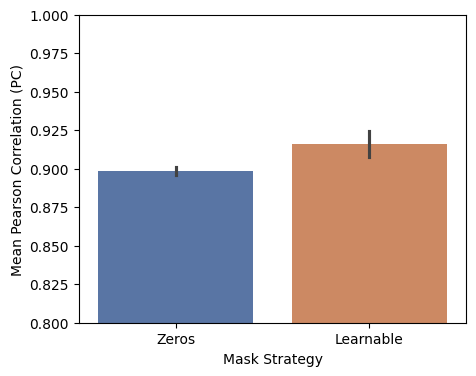

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have the DataFrame 'df' as shown in the image
# df = pd.DataFrame(...)

# Filter only the rows with the PC metric
df_pc = df_avg[df_avg['metric'] == 'PC']

# Create the plot
plt.figure(figsize=(5, 4))
sns.barplot(data=df_pc, x='Mask', y='value', hue='Mask', palette='deep', errorbar="sd", legend=False)

# Customize the plot
plt.ylabel('Mean Pearson Correlation (PC)')
plt.ylim([0.8,1])
plt.xlabel('Mask Strategy')

# Show the plot
plt.savefig("/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/paper/plots/ablations/mask_strategy.pdf")

In [23]:
df_pivot = df_avg.pivot(index='model', columns=['dataset','metric'], values='value')
model_order = ['WFM',  'SQUINT w/o C', 'SQUINT']
df_pivot = df_pivot.reindex(model_order).reset_index()
df_pivot = df_pivot.fillna('NA')

for i in range(df_pivot.shape[1]-1):
    df_pivot.insert(i*2+1,f'amps-{i}','&')
i += 1
df_pivot.insert(i*2+1,f'newline-{i}','\\\\')

display(df_pivot)

dataset,model,amps-0,Brain (Mouse),amps-1,Brain (Mouse),amps-2,Brain (Mouse),amps-3,Kidney (Human),amps-4,Kidney (Human),amps-5,Kidney (Human),amps-6,Skin (Human),amps-7,Skin (Human),amps-8,Skin (Human),newline-9
metric,,,E1,,MMD,,PC,,E1,,MMD,,PC,,E1,,MMD,,PC,
0,WFM,&,NA,&,NA,&,NA,&,NA,&,NA,&,NA,&,NA,&,NA,&,NA,\\
1,SQUINT w/o C,&,0.0077,&,0.0447,&,0.8884,&,0.0039,&,0.0254,&,0.827,&,0.012,&,0.0864,&,0.7471,\\
2,SQUINT,&,0.005,&,0.0395,&,0.9161,&,0.003,&,0.0194,&,0.8687,&,0.0129,&,0.0927,&,0.7882,\\


In [24]:
top_str = """\\begin{table*}[t]\n
\\small
\\captionsetup[sub]{skip=0pt} \n
\\centering  \n
\\setlength\\tabcolsep{3pt} \n
\\caption{2D Imputation Results.}
\label{tab:2D_imputation_results} \n
"""

header_str = """\\begin{tabular}{lccccccccc} \n
\\toprule \n
\\multirow{2}[2]{*}{\\textbf{Model}} & \\multicolumn{3}{c}{\\textbf{Brain (Mouse)}} & \\multicolumn{3}{c}{\\textbf{Kidney (Human)}} & \\multicolumn{3}{c}{\\textbf{Skin (Human)}}  \\\\ \n
\\cmidrule(lr){2-4} \\cmidrule(lr){5-7} \\cmidrule(lr){8-10} \n
& E $\\downarrow$ & MMD $\\downarrow$ & PC $\\uparrow$ & E $\\downarrow$ & MMD $\\downarrow$ & PC $\\uparrow$ & E $\\downarrow$ & MMD $\\downarrow$ & PC $\\uparrow$ \\\\ \n
\\midrule \n
"""

   # WFM &      0.1314 &     -- &      -- &  0.1118 &     -- &      -- &  0.2026 &      -- &      --         \\

data_str = df_pivot.to_string(header=False, index=False)

footer_str =  "\n\\bottomrule \n \\end{tabular} \n"

bottom_str = '\\end{table*}'


fname = save_dir / "2D_imputation_results.tex"
with open(fname, 'w') as fp:
    fp.write(top_str)
    fp.write(header_str)
    fp.write(data_str)
    fp.write(footer_str)
    fp.write(bottom_str)